In [ ]:
# project 1st file 기본 전처리(robustScaler) 후 모델 돌려보기 2025.11.26
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import os


import importlib
from utils import preprocessing
importlib.reload(preprocessing)

import utils.preprocessing as pp 
import utils.data_sampling as ds 
import utils.user_utils    as uu 

In [13]:
# data loading
df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


 결측치 정보 ======================================================================
✅ 결측치 없음

== 타겟 분포 ======================================================================

[Class] 개수:
Class
0    284315
1       492
Name: count, dtype: int64

[Class] 비율(%):
  Class 0: 99.83%
  Class 1: 0.17%
  ⚠️ 심각한 불균형 (0.17%)


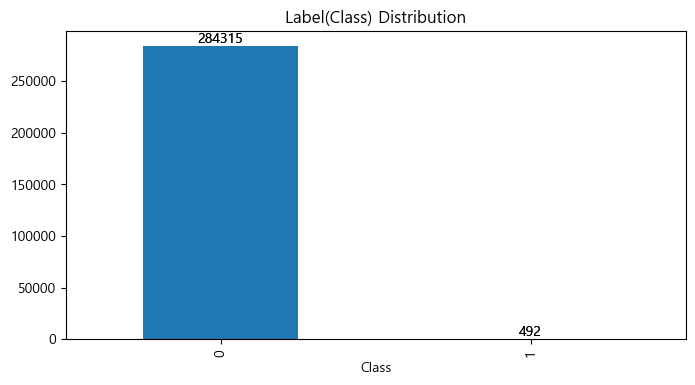

In [4]:
# 기본정보 확인
pp.checkBasicInfo(df, isInfo=False, isGraph=True)


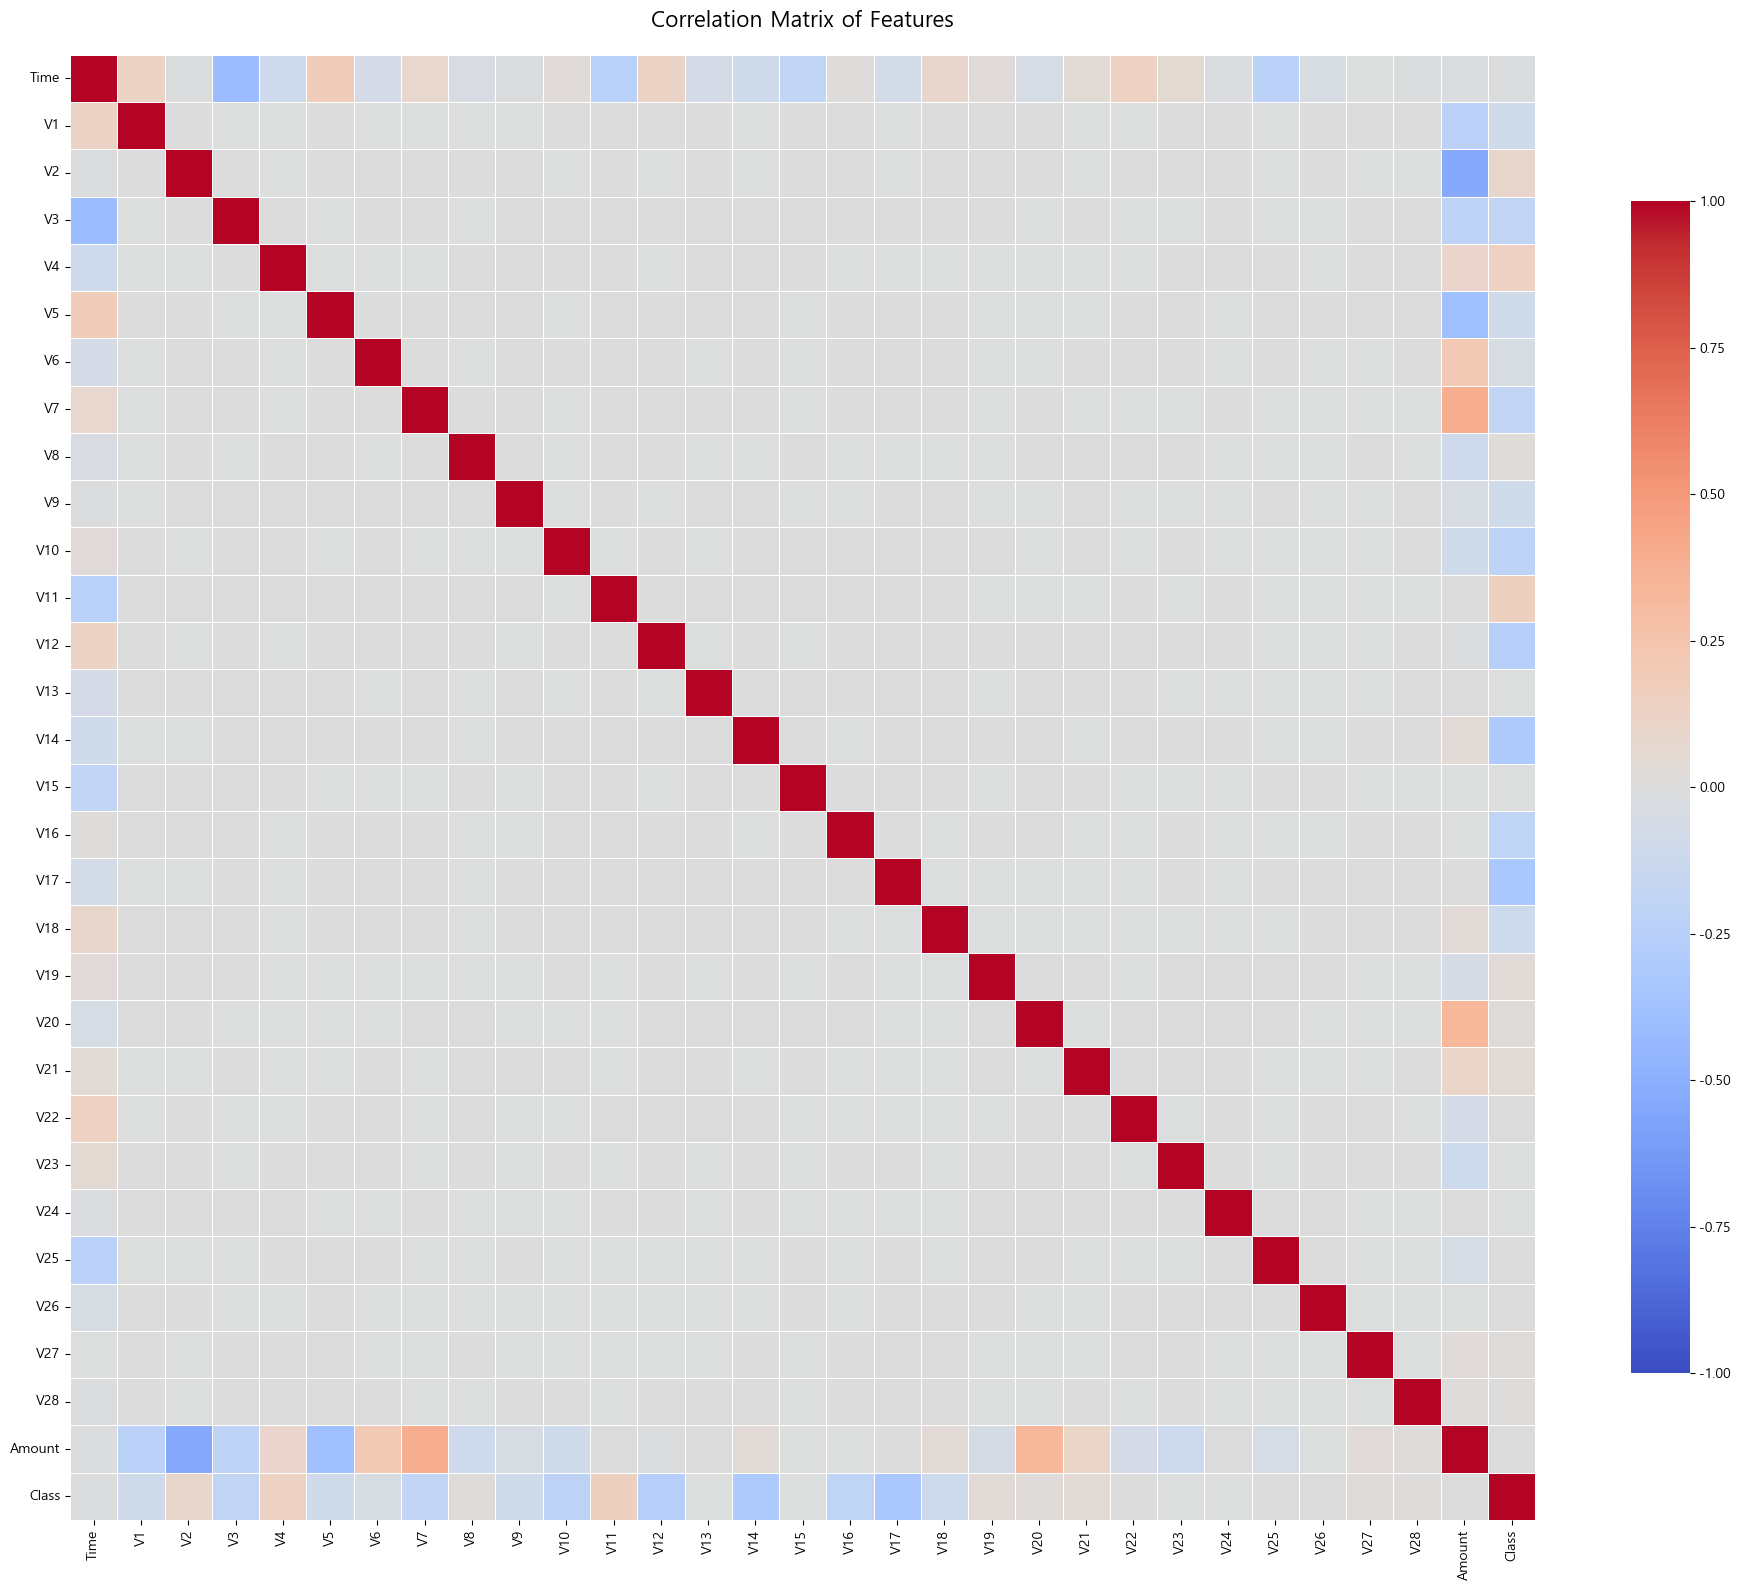

상관관계 통계 요약
평균 상관계수: -0.0065
최대 상관계수: 0.3973
최소 상관계수: -0.5314
표준편차: 0.0637

높은 상관관계 변수 쌍 (|correlation| > 0.7)
높은 상관관계 쌍이 발견되지 않았습니다.

'Time'와 상관관계가 높은 변수들 (상위 10개)

V3     0.419618
V11    0.247689
V25    0.233083
V15    0.183453
V5     0.173072
V22    0.144059
V12    0.124348
V1     0.117396
V4     0.105260
V14    0.098757

결과가 파일로 저장되었습니다: ../results/CorrWithTime_2025_1126.txt


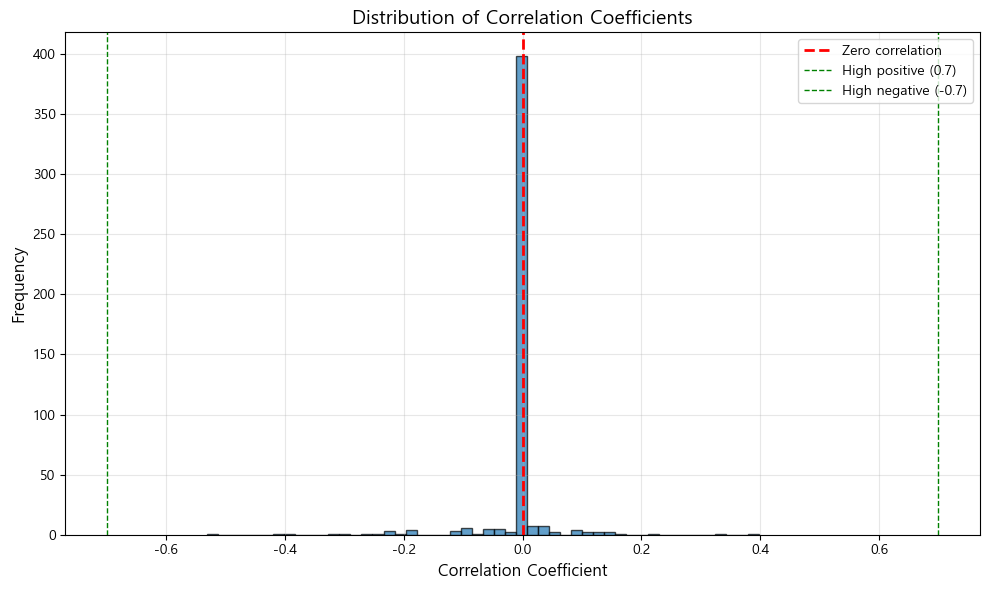

In [79]:
# 상관관계 시각화 시도
pp.corrGraph(df)    

In [ ]:
# X_features, y_target = pp.split_features_target(df, cols='Time', target_col='Class')
# df_desc_org = uu.get_outlier(X_features)


In [ ]:
# df_desc_org
# outlier_cols = df_desc_org[df_desc_org['OutlierCount'] > 10000].index.to_list()[:-1]
# outlier_cols

['V2',
 'V4',
 'V5',
 'V6',
 'V8',
 'V12',
 'V14',
 'V19',
 'V20',
 'V21',
 'V23',
 'V27',
 'V28']

In [ ]:
# df['Amount'].value_counts()
# df['Amount'].value_counts(normalize=True)
# df[df['Amount']> 184]['Amount']

2          378.66
20         231.71
51        1402.95
64         243.66
85         200.01
           ...   
284735     381.05
284748     220.28
284753     337.54
284757     200.00
284806     217.00
Name: Amount, Length: 31959, dtype: float64

In [14]:
# 2. Time 컬럼 삭제 , 데이터,타겟 분리
X_features, y_target = pp.split_features_target(df, cols= 'Time')

# 학습/데이터 분리
X_train, X_test, y_train, y_test = pp.data_split(X_features, y_target)

In [17]:
# 3.Data전처리
# Amount와 Time 스케일링 (V1-V28은 이미 PCA 처리됨)

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train_rscaled = scaler.fit_transform(X_train)   # 학습 데이터로 fit + transform
X_test_rscaled = scaler.transform(X_test)         # 테스트 데이터는 transform만


In [18]:
# Over Sampling
X_over, y_over = ds.oversampling_smote(X_train_rscaled, y_train)

✅ SMOTE 오버샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)


In [19]:
# Under Sampling
X_under, y_under = ds.undersampling_RUS(X_train_rscaled, y_train)

✅ 랜덤 언더샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 788 (Class 0: 394, Class 1: 394)
   제거된 샘플: 227057개


In [20]:
# Combined Sampling
X_combined, y_combined = ds.combined_sampling(X_train_rscaled, y_train)

✅ SMOTETomek 혼합 샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)
   최종 변화: +227057개


In [85]:
# outlier_index = get_outlier_index(df_, column=outlier_cols)
# print(f"outlier_index cnt: {len(outlier_index)}, rate:{(len(outlier_index) / df_sacled.shape[0]) * 100}%")
# outlier_index cnt: 492, rate:0.1727485630620034%

In [23]:
## 모델 학습
# - DecistionTree : ALL
# - GB(GradientBoosting) : ALL
# - SVM : ALL
# - MLPClassifier : All
from xgboost  import XGBClassifier
from xgboost  import plot_importance
# from lightgbm import LGBMClassifier
# from catboost import CatBoostClassifier
# from sklearn.ensemble       import RandomForestClassifier
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# import importlib
# import HyperParams
# importlib.reload(HyperParams)

import HyperParams          as HP # BestParams 모아둔것

In [38]:
option_name = 'XGB_ho'
results = {}

In [39]:
xgb = XGBClassifier(**HP.xgb_best_params)
results[option_name] = uu.get_model_train_eval(xgb, f'{option_name}', X_train, X_test, y_train, y_test)

✓ 모델 저장 완료: ../models\XGB_ho.pkl
  파일 크기: 0.17 MB
folder = c:\00.Study\big20\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9686, '정확도': 0.9981, '정밀도': 0.4713, '재현율': 0.8367, 'F1': 0.6029 }
{'오차행렬':
[[56772    92]
 [   16    82]] }
실행 시간: 1.041740894317627


In [41]:
results[f'{option_name}_rscaled'] = uu.get_model_train_eval(xgb, f'{option_name}_rscaled', X_train_rscaled, X_test_rscaled, y_train, y_test)

✓ 모델 저장 완료: ../models\XGB_ho_rscaled.pkl
  파일 크기: 0.17 MB
folder = c:\00.Study\big20\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9686, '정확도': 0.9981, '정밀도': 0.4713, '재현율': 0.8367, 'F1': 0.6029 }
{'오차행렬':
[[56772    92]
 [   16    82]] }
실행 시간: 1.0391058921813965


In [42]:
results[f'{option_name}_rscaled_smote'] = uu.get_model_train_eval(xgb, f'{option_name}_rscaled_smote', X_over, X_test, y_over, y_test)

✓ 모델 저장 완료: ../models\XGB_ho_rscaled_smote.pkl
  파일 크기: 0.17 MB
folder = c:\00.Study\big20\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9546, '정확도': 0.8137, '정밀도': 0.0085, '재현율': 0.9286, 'F1': 0.0169 }
{'오차행렬':
[[46260 10604]
 [    7    91]] }
실행 시간: 2.4625861644744873


In [43]:
results[f'{option_name}_rscaled_under'] = uu.get_model_train_eval(xgb, f'{option_name}_rscaled_under', X_under, X_test, y_under, y_test)


✓ 모델 저장 완료: ../models\XGB_ho_rscaled_under.pkl
  파일 크기: 0.15 MB
folder = c:\00.Study\big20\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9729, '정확도': 0.8389, '정밀도': 0.0099, '재현율': 0.9388, 'F1': 0.0197 }
{'오차행렬':
[[47692  9172]
 [    6    92]] }
실행 시간: 0.16083645820617676


In [ ]:
results[f'{option_name}_rscaled_combined'] = uu.get_model_train_eval(xgb, f'{option_name}_rscaled_combined', X_combined, X_test, y_combined, y_test)


✓ 모델 저장 완료: ../models\XGB_ho_rscaled_combined.pkl
  파일 크기: 0.17 MB
folder = c:\00.Study\big20\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9546, '정확도': 0.8137, '정밀도': 0.0085, '재현율': 0.9286, 'F1': 0.0169 }
{'오차행렬':
[[46260 10604]
 [    7    91]] }
실행 시간: 2.2771105766296387


In [ ]:
# results = {}
# results['XGB_robustScaler_HO'] = {'AUC': 0.9645, '정확도': 0.9996, '정밀도': 0.9310, '재현율': 0.8265, 'F1': 0.8757}
# results['XGB_robustScaler_HO_smote'] = {'AUC': 0.9757, '정확도': 0.9991, '정밀도': 0.6983, '재현율': 0.8265, 'F1': 0.7570}
# results['XGB_robustScaler_HO_under'] = {'AUC': 0.9725, '정확도': 0.9402, '정밀도': 0.0255, '재현율': 0.9082, 'F1': 0.0497}
# results['XGB_robustScaler_HO_combined'] = {'AUC': 0.9757, '정확도': 0.9991, '정밀도': 0.6983, '재현율': 0.8265, 'F1': 0.7570}


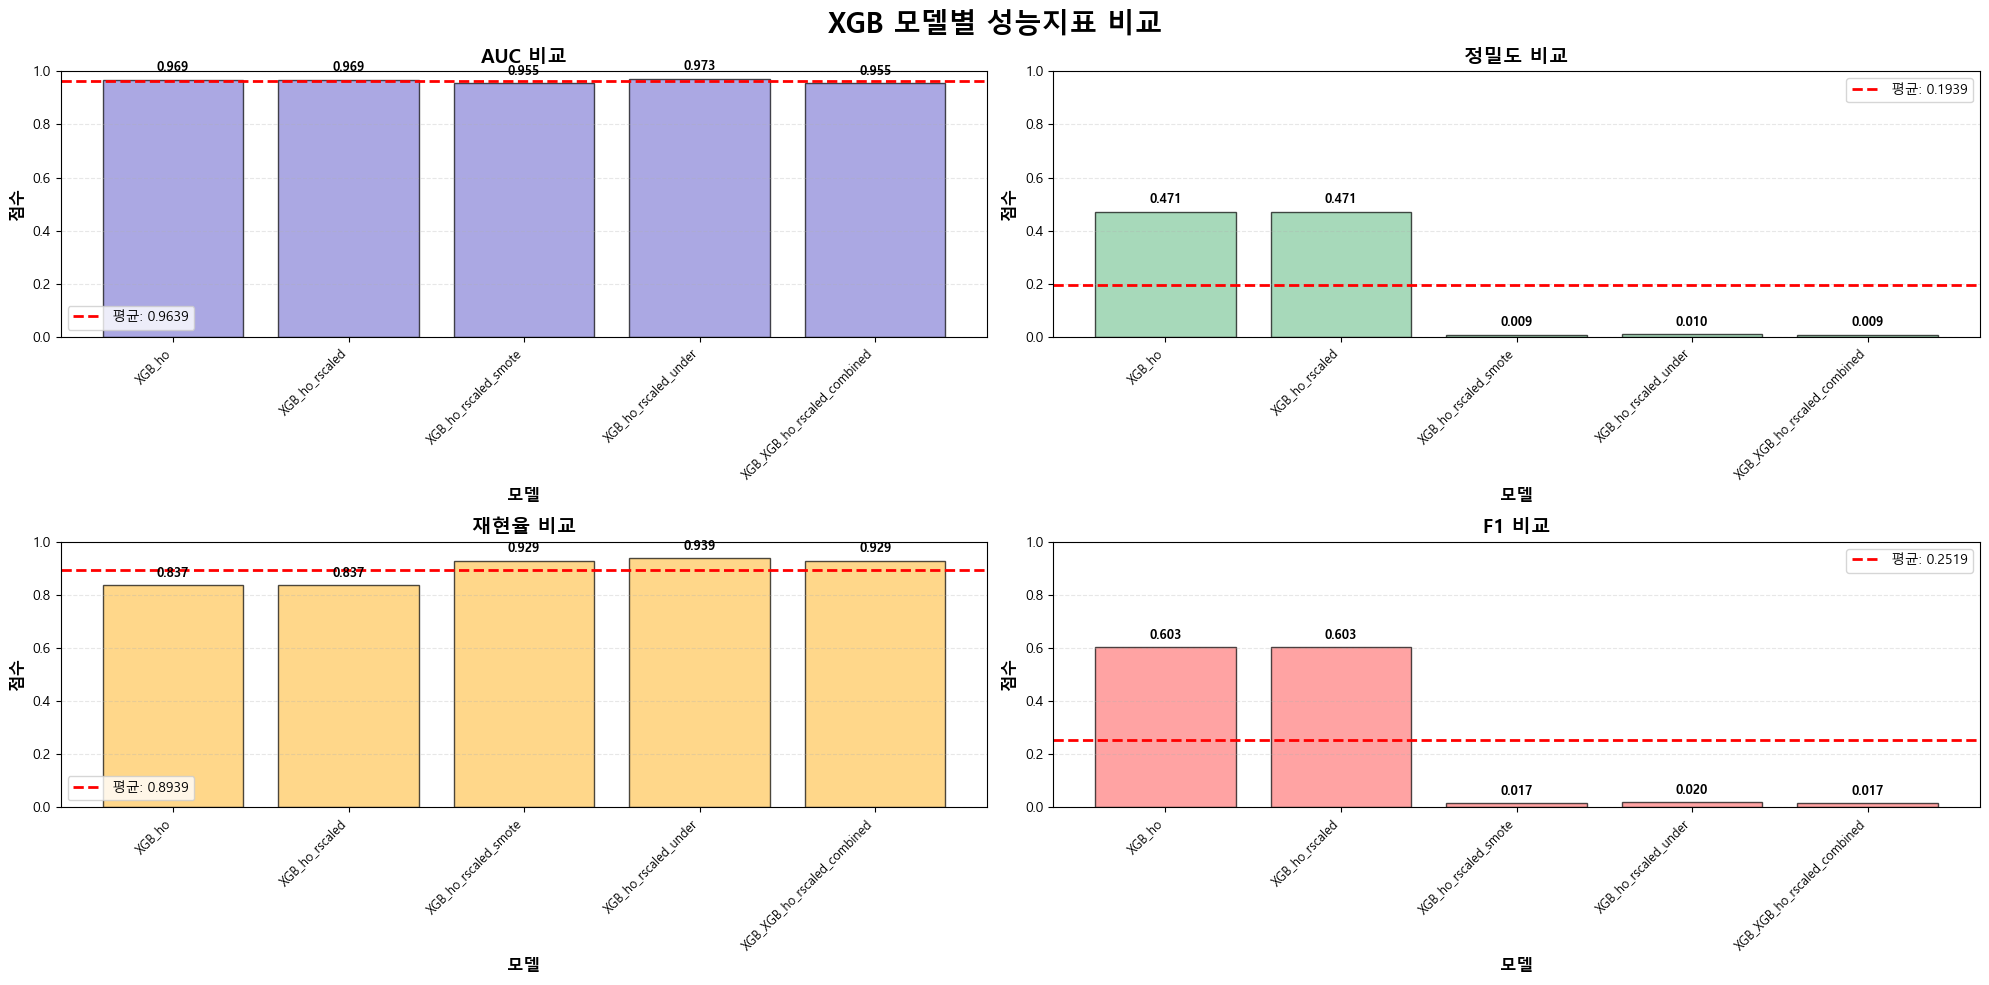


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9729 (XGB_ho_rscaled_under)
  최저: 0.9546 (XGB_ho_rscaled_smote)
  평균: 0.9639
  표준편차: 0.0086

[정밀도]
  최고: 0.4713 (XGB_ho)
  최저: 0.0085 (XGB_ho_rscaled_smote)
  평균: 0.1939
  표준편차: 0.2532

[재현율]
  최고: 0.9388 (XGB_ho_rscaled_under)
  최저: 0.8367 (XGB_ho)
  평균: 0.8939
  표준편차: 0.0524

[F1]
  최고: 0.6029 (XGB_ho)
  최저: 0.0169 (XGB_ho_rscaled_smote)
  평균: 0.2519
  표준편차: 0.3205


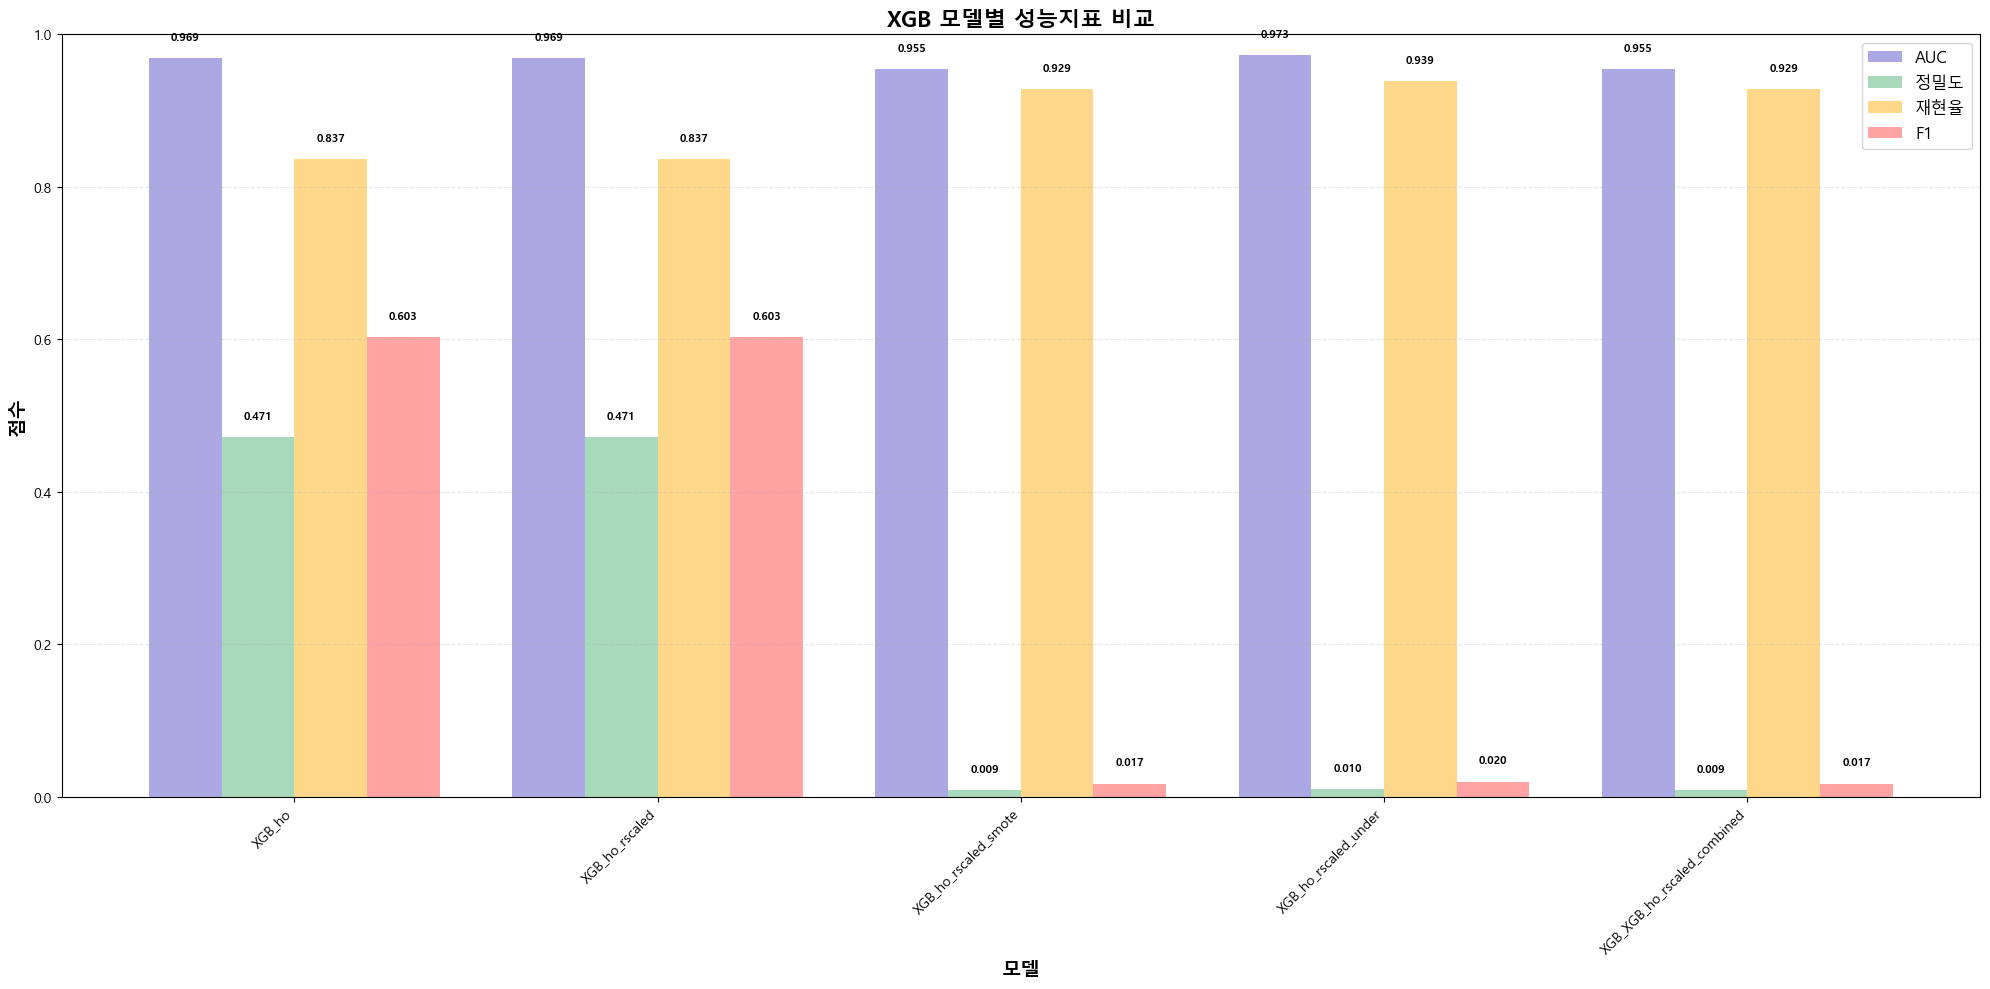


=== F1 Score 기준 상위 5개 모델 ===
                                AUC     정밀도     재현율      F1
XGB_ho                       0.9686  0.4713  0.8367  0.6029
XGB_ho_rscaled               0.9686  0.4713  0.8367  0.6029
XGB_ho_rscaled_under         0.9729  0.0099  0.9388  0.0197
XGB_ho_rscaled_smote         0.9546  0.0085  0.9286  0.0169
XGB_XGB_ho_rscaled_combined  0.9546  0.0085  0.9286  0.0169

=== AUC 기준 상위 5개 모델 ===
                                AUC     정밀도     재현율      F1
XGB_ho_rscaled_under         0.9729  0.0099  0.9388  0.0197
XGB_ho                       0.9686  0.4713  0.8367  0.6029
XGB_ho_rscaled               0.9686  0.4713  0.8367  0.6029
XGB_ho_rscaled_smote         0.9546  0.0085  0.9286  0.0169
XGB_XGB_ho_rscaled_combined  0.9546  0.0085  0.9286  0.0169

그래프가 저장되었습니다: ../images/XGB_모델별_성능지표_비교_2025_1129.png


In [45]:
# XGB 결과 시각화
from utils import modeling      as mo
mo.model_metrics_graph(results, 'XGB 모델별 성능지표 비교')

In [46]:
# 모델 생성
gb_clf = GradientBoostingClassifier(**HP.gb_basic_params)
dt_clf = DecisionTreeClassifier(**HP.dt_basic_params)
mlp_clf = MLPClassifier(**HP.mlp_basic_params)


In [ ]:
gb_option_name = 'GB_ho'
gb_results = {}
gb_results[f'{gb_option_name}'] = uu.get_model_train_eval(gb_clf,f'{option_name}',X_train,X_test,y_train,y_test)

In [ ]:
gb_results[f'{gb_option_name}_rscaled'] = uu.get_model_train_eval(gb_clf,f'{option_name}', X_train_rscaled, X_test_rscaled,y_train,y_test)
gb_results[f'{gb_option_name}_rscaled_smote'] = uu.get_model_train_eval(gb_clf,f'{option_name}_rscaled_smote', X_over,X_test,y_over,y_test)
gb_results[f'{gb_option_name}_rscaled_under'] = uu.get_model_train_eval(gb_clf,f'{option_name}_rscaled_under', X_under,X_test,y_under,y_test)
gb_results[f'{gb_option_name}_rscaled_combined'] = uu.get_model_train_eval(gb_clf,f'{option_name}_rscaled_combined', X_combined,X_test,y_combined,y_test)


In [ ]:
# results['GB_robustScaler_HO'] = {'AUC': 0.2959, '정확도': 0.9985, '정밀도': 0.7308, '재현율': 0.1939, 'F1': 0.3065}
# results['GB_robustScaler_HO_smote'] = {'AUC': 0.9750, '정확도': 0.9874, '정밀도': 0.1094, '재현율': 0.8878, 'F1': 0.1948}
# results['GB_robustScaler_HO_under'] = {'AUC': 0.9715, '정확도': 0.9597, '정밀도': 0.0367, '재현율': 0.8878, 'F1': 0.0705}
# results['GB_robustScaler_HO_combined'] = {'AUC': 0.9750, '정확도': 0.9874, '정밀도': 0.1094, '재현율': 0.8878, 'F1': 0.1948}

In [ ]:
option_name = 'dt_ho'
dt_results = {}
dt_results[f'{option_name}'] = uu.get_model_train_eval(dt_clf,f'{option_name}',X_train,X_test,y_train,y_test)
dt_results[f'{option_name}_rscaled'] = uu.get_model_train_eval(dt_clf,f'{option_name}_rscaled',X_train_rscaled,X_test_rscaled,y_train,y_test)
dt_results[f'{option_name}_rscaled_smote'] = uu.get_model_train_eval(dt_clf,f'{option_name}_rscaled_smote', X_over, X_test, y_over, y_test)
dt_results[f'{option_name}_rscaled_under'] = uu.get_model_train_eval(dt_clf,f'{option_name}_rscaled_under', X_under,X_test,y_under, y_test)
dt_results[f'{option_name}_rscaled_combined'] = uu.get_model_train_eval(dt_clf,f'{option_name}_rscaled_combined', X_combined, X_test, y_combined, y_test)

In [ ]:
# results['DT_robustScaler_HO'] = {'AUC': 0.8926, '정확도': 0.9992, '정밀도': 0.7549, '재현율': 0.7857, 'F1': 0.7700}
# results['DT_robustScaler_HO_smote'] = {'AUC': 0.8714, '정확도': 0.9974, '정밀도': 0.3744, '재현율': 0.7449, 'F1': 0.4983}
# results['DT_robustScaler_HO_under'] = {'AUC': 0.9125, '정확도': 0.9169, '정밀도': 0.0185, '재현율': 0.9082, 'F1': 0.0362}
# results['DT_robustScaler_HO_combined'] = {'AUC': 0.8714, '정확도': 0.9974, '정밀도': 0.3744, '재현율': 0.7449, 'F1': 0.4983}

In [ ]:
# results['mlp_robustScaler_HO'] = uu.get_model_train_eval(mlp_clf,f'mlp_{option_name}',X_train,X_test,y_train,y_test)
# results['mlp_robustScaler_HO_smote'] = uu.get_model_train_eval(mlp_clf,f'mlp_{option_name}_smote',X_over,X_test,y_over,y_test)

✓ 모델 저장 완료: ../models\mlp_robustScaler_HO_smote.pkl
  파일 크기: 0.13 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9663, '정확도': 0.9991, '정밀도': 0.7182, '재현율': 0.8061, 'F1': 0.7596 }
{'오차행렬':
[[56833    31]
 [   19    79]] }
실행 시간: 63.215187549591064


In [ ]:
# results['mlp_robustScaler_HO_under'] = uu.get_model_train_eval(mlp_clf,f'mlp_{option_name}_under',X_under,X_test,y_under,y_test)
# results['mlp_robustScaler_HO_under'] = {'AUC': 0.9719, '정확도': 0.9682, '정밀도': 0.0461, '재현율': 0.8878, 'F1': 0.0877 }

✓ 모델 저장 완료: ../models\mlp_robustScaler_HO_under.pkl
  파일 크기: 0.13 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9719, '정확도': 0.9682, '정밀도': 0.0461, '재현율': 0.8878, 'F1': 0.0877 }
{'오차행렬':
[[55064  1800]
 [   11    87]] }
실행 시간: 0.2790043354034424


c:\ProgramData\anaconda3\envs\ml_dev\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# results['mlp_robustScaler_HO_combined'] = uu.get_model_train_eval(mlp_clf,f'mlp_{option_name}_combined',X_combined,X_test,y_combined,y_test)


✓ 모델 저장 완료: ../models\mlp_robustScaler_HO_combined.pkl
  파일 크기: 0.13 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9663, '정확도': 0.9991, '정밀도': 0.7182, '재현율': 0.8061, 'F1': 0.7596 }
{'오차행렬':
[[56833    31]
 [   19    79]] }
실행 시간: 60.92677307128906


In [21]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(**HP.meta_best_params)


In [ ]:
# results['lr_robustScaler_HO'] = uu.get_model_train_eval(lr_clf,f'lr_{option_name}',X_train,X_test,y_train,y_test)


✓ 모델 저장 완료: ../models\lr_robustScaler_HO.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9605, '정확도': 0.9764, '정밀도': 0.0613, '재현율': 0.8878, 'F1': 0.1147 }
{'오차행렬':
[[55532  1332]
 [   11    87]] }
실행 시간: 4.075170040130615


In [ ]:
# results['lr_robustScaler_HO_smote'] = uu.get_model_train_eval(lr_clf,f'lr_{option_name}_smote', X_over,X_test,y_over,y_test)


✓ 모델 저장 완료: ../models\lr_robustScaler_HO_smote.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9601, '정확도': 0.9754, '정밀도': 0.0583, '재현율': 0.8776, 'F1': 0.1093 }
{'오차행렬':
[[55474  1390]
 [   12    86]] }
실행 시간: 5.595563888549805


In [ ]:
# results['lr_robustScaler_HO_under'] = uu.get_model_train_eval(lr_clf, f'lr_{option_name}_under', X_under,X_test,y_under,y_test)


✓ 모델 저장 완료: ../models\lr_robustScaler_HO_under.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9689, '정확도': 0.9838, '정밀도': 0.0862, '재현율': 0.8776, 'F1': 0.1569 }
{'오차행렬':
[[55952   912]
 [   12    86]] }
실행 시간: 2.2860300540924072


In [ ]:
# results['lr_robustScaler_HO_combined'] = uu.get_model_train_eval(lr_clf, f'lr_{option_name}_combined', X_combined,X_test,y_combined,y_test)


✓ 모델 저장 완료: ../models\lr_robustScaler_HO_combined.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9601, '정확도': 0.9754, '정밀도': 0.0583, '재현율': 0.8776, 'F1': 0.1093 }
{'오차행렬':
[[55474  1390]
 [   12    86]] }
실행 시간: 4.634935140609741


In [ ]:
results = {}
results['XGB_robustScaler_HO'] = {'AUC': 0.9645, '정확도': 0.9996, '정밀도': 0.9310, '재현율': 0.8265, 'F1': 0.8757}
results['XGB_robustScaler_HO_smote'] = {'AUC': 0.9757, '정확도': 0.9991, '정밀도': 0.6983, '재현율': 0.8265, 'F1': 0.7570}
results['XGB_robustScaler_HO_under'] = {'AUC': 0.9725, '정확도': 0.9402, '정밀도': 0.0255, '재현율': 0.9082, 'F1': 0.0497}
results['XGB_robustScaler_HO_combined'] = {'AUC': 0.9757, '정확도': 0.9991, '정밀도': 0.6983, '재현율': 0.8265, 'F1': 0.7570}

results['GB_robustScaler_HO'] = {'AUC': 0.2959, '정확도': 0.9985, '정밀도': 0.7308, '재현율': 0.1939, 'F1': 0.3065}
results['GB_robustScaler_HO_smote'] = {'AUC': 0.9750, '정확도': 0.9874, '정밀도': 0.1094, '재현율': 0.8878, 'F1': 0.1948}
results['GB_robustScaler_HO_under'] = {'AUC': 0.9715, '정확도': 0.9597, '정밀도': 0.0367, '재현율': 0.8878, 'F1': 0.0705}
results['GB_robustScaler_HO_combined'] = {'AUC': 0.9750, '정확도': 0.9874, '정밀도': 0.1094, '재현율': 0.8878, 'F1': 0.1948}

results['DT_robustScaler_HO'] = {'AUC': 0.8926, '정확도': 0.9992, '정밀도': 0.7549, '재현율': 0.7857, 'F1': 0.7700}
results['DT_robustScaler_HO_smote'] = {'AUC': 0.8714, '정확도': 0.9974, '정밀도': 0.3744, '재현율': 0.7449, 'F1': 0.4983}
results['DT_robustScaler_HO_under'] = {'AUC': 0.9125, '정확도': 0.9169, '정밀도': 0.0185, '재현율': 0.9082, 'F1': 0.0362}
results['DT_robustScaler_HO_combined'] = {'AUC': 0.8714, '정확도': 0.9974, '정밀도': 0.3744, '재현율': 0.7449, 'F1': 0.4983}

results['mlp_robustScaler_HO'] = { 'AUC': 0.9652, '정확도': 0.9995, '정밀도': 0.9080, '재현율': 0.8061, 'F1': 0.8541}
results['mlp_robustScaler_HO_smote'] = {'AUC': 0.9663, '정확도': 0.9991, '정밀도': 0.7182, '재현율': 0.8061, 'F1': 0.7596 }
results['mlp_robustScaler_HO_under'] = {'AUC': 0.9719, '정확도': 0.9682, '정밀도': 0.0461, '재현율': 0.8878, 'F1': 0.0877 }
results['mlp_robustScaler_HO_combined'] = {'AUC': 0.9663, '정확도': 0.9991, '정밀도': 0.7182, '재현율': 0.8061, 'F1': 0.7596 }

results['lr_robustScaler_HO'] = {'AUC': 0.9605, '정확도': 0.9764, '정밀도': 0.0613, '재현율': 0.8878, 'F1': 0.1147}
results['lr_robustScaler_HO_smote'] = {'AUC': 0.9601, '정확도': 0.9754, '정밀도': 0.0583, '재현율': 0.8776, 'F1': 0.1093 }
results['lr_robustScaler_HO_under'] = {'AUC': 0.9689, '정확도': 0.9838, '정밀도': 0.0862, '재현율': 0.8776, 'F1': 0.1569 }
results['lr_robustScaler_HO_combined'] = {'AUC': 0.9601, '정확도': 0.9754, '정밀도': 0.0583, '재현율': 0.8776, 'F1': 0.1093 }

In [ ]:
from sklearn.svm import SVC

# 5. Linear SVM
svc_liner_basic_params = {
  'C' : 1.0, 
  'kernel' : "linear", 
  'class_weight' : "balanced"
}
linear_svm = SVC(**svc_liner_basic_params)  # 불균형 데이터라 balanced 권장
resutls_scr='''
✓ 모델 저장 완료: ../models\lsvm_robustScaler_HO.pkl
  파일 크기: 6.25 MB
'''

# results[f'lsvm_{option_name}'] = uu.get_model_train_eval(linear_svm, f'lsvm_{option_name}', X_train,X_test,y_train,y_test)


In [ ]:
from sklearn.metrics import classification_report

linear_svm.fit(X_train, y_train)
y_pred_linear = linear_svm.predict(X_test)

print("=== Linear SVM ===")
print(classification_report(y_test, y_pred_linear, digits=4))


In [ ]:
# results[f'lsvm_{option_name}_smote'] = uu.get_model_train_eval(linear_svm, f'lsvm_{option_name}_smote', X_over,X_test,y_oever,y_test)

In [ ]:
# results[f'lsvm_{option_name}_under'] = uu.get_model_train_eval(linear_svm, f'lsvm_{option_name}_under', X_under,X_test,y_under,y_test)


In [ ]:
# results[f'lsvm_{option_name}_combined'] = uu.get_model_train_eval(linear_svm, f'lsvm_{option_name}_combined', X_combined,X_test,y_combined,y_test)

In [ ]:
# 6. RBF SVM
svc_rbf_basic_params = {
  'C' : 1.0, 
  'kernel' : "rbf", 
  'gamma' : "scale",
  'class_weight' : "balanced"  
}
rbf_svm = SVC(**svc_rbf_basic_params)
# rbf_svm.fit(X_train, y_train)
# y_pred_rbf = rbf_svm.predict(X_test)

# print("=== RBF SVM ===")
# print(classification_report(y_test, y_pred_rbf, digits=4))



In [ ]:
df_results = pd.DataFrame(results).T